# import necessary packages

In [47]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
random.seed(0)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Plotting functions

In [48]:
def plot_polynomial_regression(model, X , Y , degree, X_test = None , Y_test = None):
     
        # Plots the original data points and the polynomial regression curve,
        # optionally including test data points.

        # Args:
        # model: The trained scikit-learn model object.
        # X: Input features (list or numpy array).
        # Y: Input labels (list or numpy array).
        # degree: The degree of the polynomial used for training.
        # X_test: Optional test set features (list or numpy array).
        # Y_test: Optional test set labels (list or numpy array).
    
    X = np.array(X).reshape(-1,1)
    Y = np.array(Y)

    # Generate predicted value for plotting the curve
    X_plot = np.linspace(np.min(X), np.max(X), 100).reshape(-1,1)
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_plot_poly =  poly.fit_transform(X_plot)

    Y_plot_poly = model.predict(X_plot_poly)
    
    # Plot the original points
    plt.scatter(X, Y, color='blue', label = 'Origin data')
    
    # Plot the polynomial regression curve
    plt.plot(X_plot,Y_plot_poly,color = 'red' , label =f'Polynomial Regression (degree {degree})')


    # Plot test data if it is provided
    if X_test is not None and Y_test is not None:
        X_test = np.array(X_test).reshape(-1,1)
        Y_test = np.array(Y_test)
        plt.scatter(X_test, Y_test, color ='orange',marker='^', label='Test Data')
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.legend()
    plt.grid(True)

    #Set plot bounds based on X and Y
    plt.xlim(np.min(X),np.max(X))
    plt.ylim(np.min(Y) , np.max(Y))

    plt.show()

# Defining our dataset

Plotting the polynomial $-x^3 + 2x^2 + x +2$


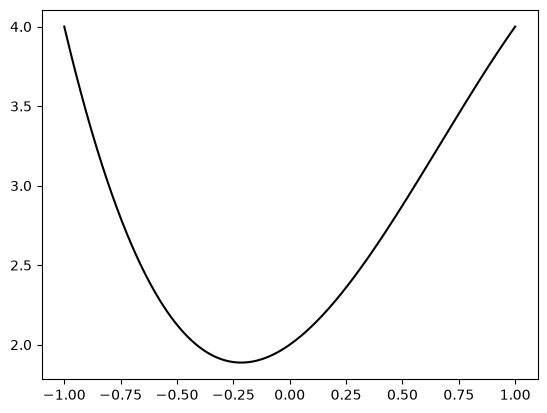

In [49]:
coefs = [2,1 ,2,-1]

def polynomial(coefs, x):
    n = len(coefs)
    return sum(coefs[i]*x**i for i in range(n))

def draw_polynomial(coefs):
    x = np.linspace(-1,1,1000)
    plt.plot(x,polynomial(coefs,x), linestyle='-',color ='black')

draw_polynomial(coefs)

Generating a dataset of 50 points 

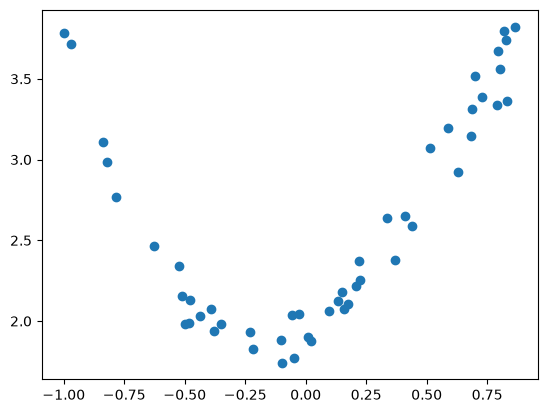

In [50]:
X = []
Y = []

for i in range(50):
    x = random.uniform(-1,1)
    y = polynomial(coefs,x) + random.gauss(0,0.1)
    X.append(x)
    Y.append(y)

plt.scatter(X,Y)

# Training a polynomial regression model

Plot a polynomial of degree 20 to our dataset. To observe how much it overfits

In [51]:
def train_model_regression(X, Y, degree, regularization = None, alpha = 1.0):
    X = np.array(X).reshape(-1,1)
    Y = np.array(Y)

    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_poly = poly.fit_transform(X)

    if regularization == 'L1':
        model = Lasso(alpha=alpha)
    elif regularization == 'L2':
        model = Ridge(alpha=alpha)
    else:
        model = LinearRegression()
    model.fit(X_poly,Y)

    return model

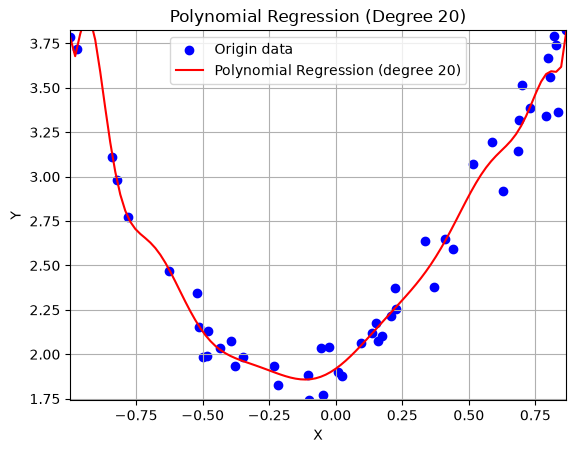

In [52]:
degree_used = 20
model = train_model_regression(X, Y, degree=degree_used)
plot_polynomial_regression(model, X, Y, degree_used)

# Splitting data into training and testing

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y , test_size=0.2, random_state=0)

print("Shape of X_train:", np.shape(X_train))
print("Shape of X_test:", np.shape(X_test))
print("Shape of Y_train:", np.shape(Y_train))
print("Shape of Y_test:", np.shape(Y_test))

Shape of X_train: (40,)
Shape of X_test: (10,)
Shape of Y_train: (40,)
Shape of Y_test: (10,)


# Training a polynomial regression model with no regularization

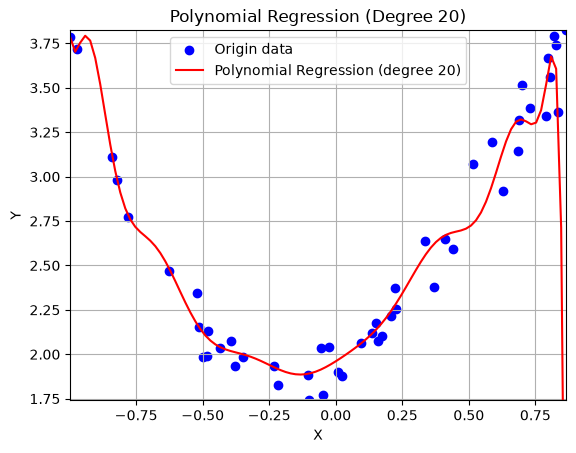

In [54]:
model_no_reg =train_model_regression(X_train,Y_train,degree_used)
plot_polynomial_regression(model_no_reg, X, Y, degree_used)

In [55]:
def evaluate_model(model, X_test, Y_test ,degree):
    X_test = np.array(X_test).reshape(-1,1)
    Y_test = np.array(Y_test)

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_test_poly = poly.fit_transform(X_test)

    y_pred = model.predict(X_test_poly)

    rmse = np.sqrt(mean_squared_error(Y_test,y_pred))

    return rmse

In [56]:
square_loss_no_reg = evaluate_model(model_no_reg,X_test,Y_test,degree_used)
print(f"Square test on the test set (degree {degree_used}): {square_loss_no_reg}")

Square test on the test set (degree 20): 1.298105804691898


# Training a polynomial regression model with L1 regularization

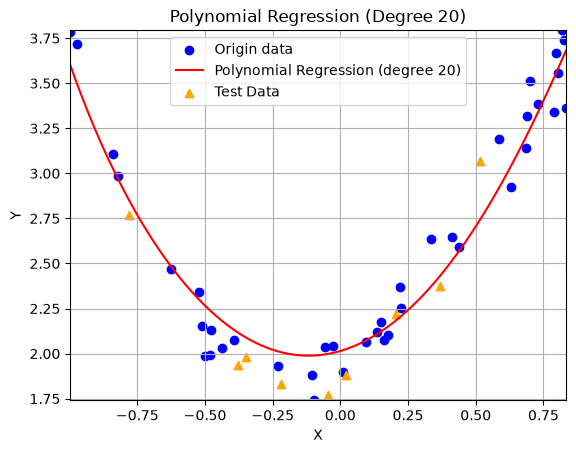

In [57]:
l1_penalty = 0.01

model_L1_reg = train_model_regression(X_train,Y_train, degree_used, 'L1' , l1_penalty)
plot_polynomial_regression(model_L1_reg,X_train,Y_train, degree_used, X_test, Y_test)

In [58]:
square_loss_L1_reg = evaluate_model(model_L1_reg,X_test,Y_test,degree_used)
print(f"Square test on the test set (degree {degree_used}): {square_loss_L1_reg}")

Square test on the test set (degree 20): 0.16482899488976088


# Training a polynomial regression model with L2 regularization

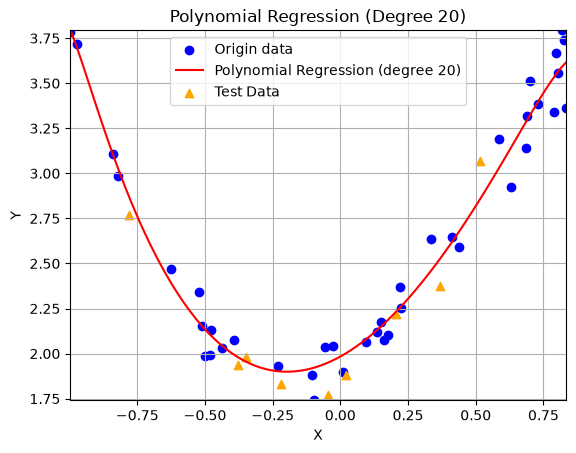

In [59]:
L2_pelnaty = 0.01

model_L2_reg=  train_model_regression(X_train, Y_train , degree_used, 'L2', L2_pelnaty)
plot_polynomial_regression(model_L2_reg,X_train,Y_train,degree_used,X_test,Y_test)

In [60]:
square_loss_L2_reg = evaluate_model(model_L2_reg,X_test,Y_test,degree_used)
print(f"Square test on the test set (degree {degree_used}): {square_loss_L2_reg}")

Square test on the test set (degree 20): 0.12869451293440523


# Exploring the coefficients of the models

In [61]:
print("Coefficients of the model with no regularization")
print(model_no_reg.intercept_)
print(model_no_reg.coef_)
print()
print("Coefficients of the model with L1 regularization")
print(model_L1_reg.intercept_)
print(model_L1_reg.coef_)
print()
print("Coefficients of the model with L2 regularization")
print(model_L2_reg.intercept_)
print(model_L2_reg.coef_)

Coefficients of the model with no regularization
1.9604785640256108
[ 9.43851807e-01  1.48085587e+00 -7.77732881e+00  4.47595838e+01
  1.41428396e+02 -4.41254027e+02 -1.02063448e+03  1.49509834e+03
  3.08171385e+03 -1.55891983e+03 -3.29669237e+03 -9.47288704e+02
 -1.36361087e+03  1.26943836e+03  3.05626437e+03  1.60458632e+03
  2.75774841e+03 -5.41737421e+01 -3.73344991e+03 -1.79593733e+03]

Coefficients of the model with L1 regularization
2.0145160556628996
[ 0.44039717  1.87049028 -0.          0.06353345 -0.          0.
 -0.1041436   0.         -0.          0.         -0.          0.
 -0.          0.         -0.          0.         -0.          0.
 -0.          0.        ]

Coefficients of the model with L2 regularization
1.9839731961541232
[ 0.83144763  1.92829446 -0.54970599  0.19338118 -0.15186449 -0.05201394
 -0.01849073 -0.0784759  -0.03963599 -0.06959908 -0.08458939 -0.06115837
 -0.1069912  -0.06223285 -0.10030261 -0.07400616 -0.07069915 -0.09506528
 -0.0262719  -0.12333552]


# Summary
- The model with no regularization lead to overfitting
- The models with regularization by using L1 or L2 have less complextity and give the better result
- We should split the data in 8 - 2 (8 for training - 2 for testing) or 6 - 2 - 2 (6 for training - 2 for validation - 2 for testing)
